# Computacion paralela y distribuida
## Tarea 3: Polars
## Jean Carlo Rabbat

In [20]:
import sys
sys.path.append('..')
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
import psutil
from src.polars_pipeline import load_and_process_polars, get_system_info
from src.pandas_pipeline import load_and_process_pandas
from src.preprocessing import prepare_data
from src.feature_engineering import create_features
from src.train_models import train_and_evaluate_models
from sklearn.metrics import confusion_matrix
plt.rcParams['figure.figsize'] = (12, 6)

### Parte 1: Análisis Exploratorio

In [21]:
df = pl.read_csv("../data/raw/creditcard.csv", infer_schema_length=10000, ignore_errors=True)

print(f"\nDataset cargado: {df.shape}")
print(f"Columnas: {df.columns}")

print("\n" + "-"*60)
print("Estadísticas descriptivas")
print("-"*60)
print(df.describe())


Dataset cargado: (284807, 31)
Columnas: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

------------------------------------------------------------
Estadísticas descriptivas
------------------------------------------------------------
shape: (9, 32)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ statistic ┆ Time      ┆ V1        ┆ V2        ┆ … ┆ V27       ┆ V28       ┆ Amount    ┆ Class    │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│ str       ┆ f64       ┆ f64       ┆ f64       ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ count     ┆ 284806.0  ┆ 284807.0  ┆ 284807.0  ┆ … ┆ 284807.0  ┆ 284807.0 

In [22]:
print("\n" + "-"*60)
print("Valores faltantes")
print("-"*60)
null_counts = df.null_count()
print(null_counts)

if null_counts.to_series().sum() == 0:
    print("\nNo hay valores faltantes")


------------------------------------------------------------
Valores faltantes
------------------------------------------------------------
shape: (1, 31)
┌──────┬─────┬─────┬─────┬───┬─────┬─────┬────────┬───────┐
│ Time ┆ V1  ┆ V2  ┆ V3  ┆ … ┆ V27 ┆ V28 ┆ Amount ┆ Class │
│ ---  ┆ --- ┆ --- ┆ --- ┆   ┆ --- ┆ --- ┆ ---    ┆ ---   │
│ u32  ┆ u32 ┆ u32 ┆ u32 ┆   ┆ u32 ┆ u32 ┆ u32    ┆ u32   │
╞══════╪═════╪═════╪═════╪═══╪═════╪═════╪════════╪═══════╡
│ 1    ┆ 0   ┆ 0   ┆ 0   ┆ … ┆ 0   ┆ 0   ┆ 0      ┆ 0     │
└──────┴─────┴─────┴─────┴───┴─────┴─────┴────────┴───────┘


In [23]:
print("\n" + "-"*60)
print("Variable objetivo (Class)")
print("-"*60)

class_counts = df.group_by("Class").agg(pl.count().alias("count")).sort("Class")
print(class_counts)

total = df.shape[0]
legit = df.filter(pl.col("Class") == 0).shape[0]
fraud = df.filter(pl.col("Class") == 1).shape[0]

print(f"\nLegitimas: {legit:,} ({(legit/total)*100:.2f}%)")
print(f"Fraude: {fraud:,} ({(fraud/total)*100:.2f}%)")
print(f"Ratio: 1 fraude por cada {legit/fraud:.0f} legitimas")


------------------------------------------------------------
Variable objetivo (Class)
------------------------------------------------------------
shape: (2, 2)
┌───────┬────────┐
│ Class ┆ count  │
│ ---   ┆ ---    │
│ i64   ┆ u32    │
╞═══════╪════════╡
│ 0     ┆ 284315 │
│ 1     ┆ 492    │
└───────┴────────┘

Legitimas: 284,315 (99.83%)
Fraude: 492 (0.17%)
Ratio: 1 fraude por cada 578 legitimas


C:\Users\jrabbat\AppData\Local\Temp\ipykernel_47952\4132286506.py:5: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  class_counts = df.group_by("Class").agg(pl.count().alias("count")).sort("Class")


In [24]:
print("\n" + "=" * 60)
print("Variable objetivo (Class)")
print("=" * 60)

class_counts = df.group_by("Class").agg(pl.count().alias("count")).sort("Class")
print(class_counts)

total = df.shape[0]
legit = df.filter(pl.col("Class") == 0).shape[0]
fraud = df.filter(pl.col("Class") == 1).shape[0]

print(f"\nLegitimas: {legit:,} ({(legit/total)*100:.2f}%)")
print(f"Fraude: {fraud:,} ({(fraud/total)*100:.2f}%)")
print(f"Ratio: 1 fraude por cada {legit/fraud:.0f} legitimas")


Variable objetivo (Class)
shape: (2, 2)
┌───────┬────────┐
│ Class ┆ count  │
│ ---   ┆ ---    │
│ i64   ┆ u32    │
╞═══════╪════════╡
│ 0     ┆ 284315 │
│ 1     ┆ 492    │
└───────┴────────┘

Legitimas: 284,315 (99.83%)
Fraude: 492 (0.17%)
Ratio: 1 fraude por cada 578 legitimas


C:\Users\jrabbat\AppData\Local\Temp\ipykernel_47952\1838938687.py:5: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  class_counts = df.group_by("Class").agg(pl.count().alias("count")).sort("Class")



------------------------------------------------------------
Gráficas de distribución
------------------------------------------------------------


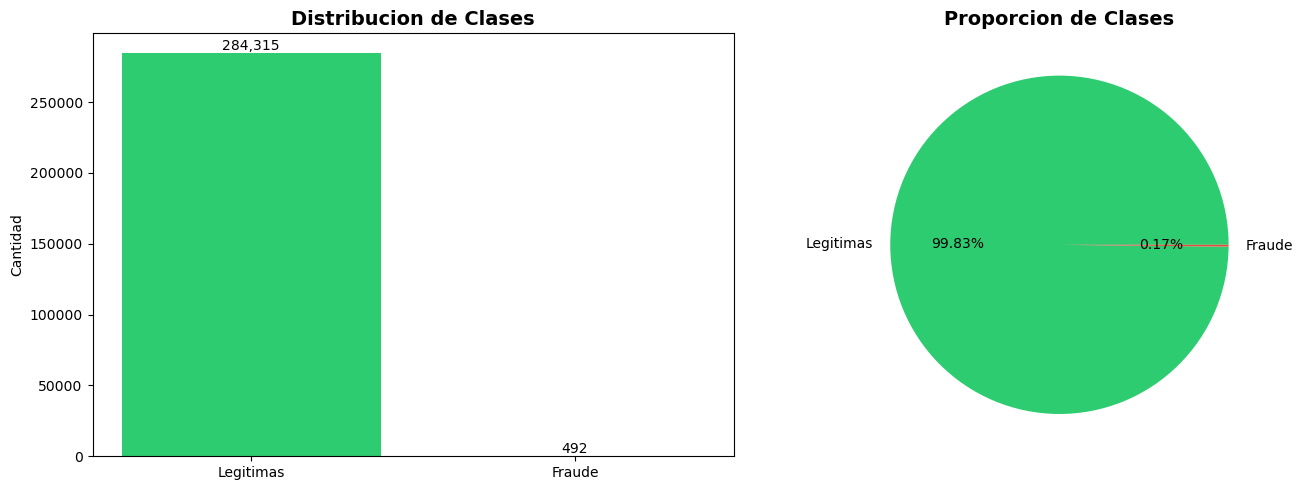

Grafico guardado


In [25]:
print("\n" + "-"*60)
print("Gráficas de distribución")
print("-"*60)

os.makedirs("../figures", exist_ok=True)

class_counts_pd = class_counts.to_pandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(['Legitimas', 'Fraude'], class_counts_pd['count'], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribucion de Clases', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Cantidad')
for i, v in enumerate(class_counts_pd['count']):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom')

axes[1].pie(class_counts_pd['count'], 
            labels=['Legitimas', 'Fraude'],
            autopct='%1.2f%%',
            colors=['#2ecc71', '#e74c3c'])
axes[1].set_title('Proporcion de Clases', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig("../figures/01_class_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

print("Grafico guardado")

In [26]:
print("\n" + "-"*60)
print("Correlaciones con fraude")
print("-"*60)

df_pd = df.to_pandas()
corr = df_pd.corr()

top_corr = corr['Class'].drop('Class').abs().sort_values(ascending=False).head(10)

print("\nTop 10 caracteristicas:")
for i, (col, val) in enumerate(top_corr.items(), 1):
    print(f"{i}. {col}: {val:.4f}")


------------------------------------------------------------
Correlaciones con fraude
------------------------------------------------------------

Top 10 caracteristicas:
1. V17: 0.3265
2. V14: 0.3025
3. V12: 0.2606
4. V10: 0.2169
5. V16: 0.1965
6. V3: 0.1930
7. V7: 0.1873
8. V11: 0.1549
9. V4: 0.1334
10. V18: 0.1115



------------------------------------------------------------
Heatmap de correlaciones
------------------------------------------------------------


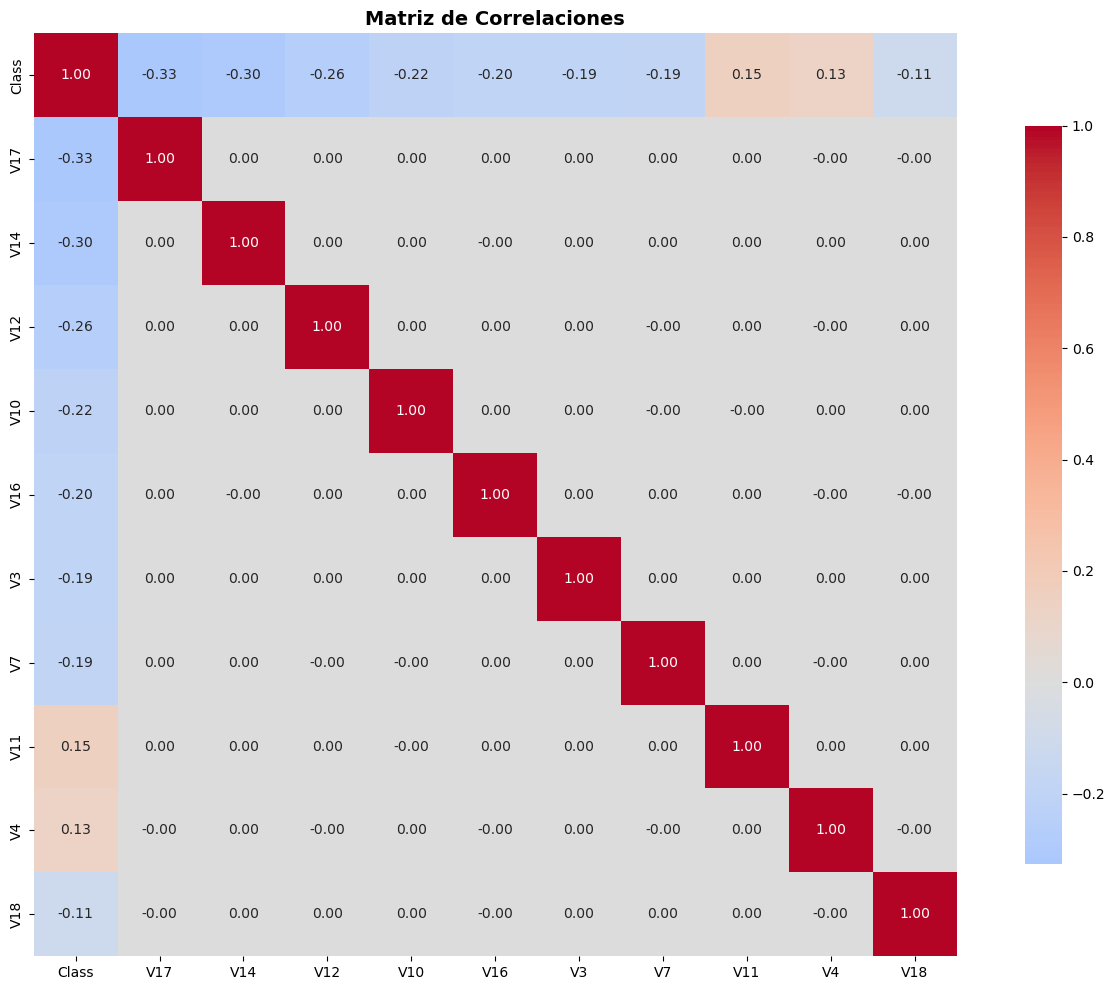

Heatmap guardado


In [27]:
print("\n" + "-"*60)
print("Heatmap de correlaciones")
print("-"*60)

top_features = ['Class'] + top_corr.head(14).index.tolist()
corr_matrix = corr[top_features].loc[top_features]

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlaciones', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("../figures/02_correlation_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

print("Heatmap guardado")


## Parte 2: Ingeniería de Características

In [28]:
print("\nFiltrado de registros")
df_filtered = df.filter(pl.col("Amount") > 0)
print(f"Registros originales: {df.shape[0]}")
print(f"Registros después de filtrar: {df_filtered.shape[0]}")

print("\nTransformación de variables")
df_transformed = df_filtered.with_columns(
    (pl.col("Amount") / pl.col("Amount").max()).alias("amount_scaled")
)
print("Variables transformadas")

print("\nAgregación con group_by")
stats = df_transformed.group_by("Class").agg(
    pl.col("Amount").mean().alias("avg_amount")
)
print("Estadisticas por clase:")
print(stats)

print("\nJoin con estadísticas")
df_with_stats = df_transformed.join(stats, on="Class")
print(f"Dataset con estadisticas: {df_with_stats.shape}")

print("\nCreación de nuevas características")
df_final = df_with_stats.with_columns(
    (pl.col("Amount") - pl.col("avg_amount")).alias("amount_diff")
)
print(f"Features finales: {df_final.shape[1]} variables")



Filtrado de registros
Registros originales: 284807
Registros después de filtrar: 282982

Transformación de variables
Variables transformadas

Agregación con group_by
Estadisticas por clase:
shape: (2, 2)
┌───────┬────────────┐
│ Class ┆ avg_amount │
│ ---   ┆ ---        │
│ i64   ┆ f64        │
╞═══════╪════════════╡
│ 0     ┆ 88.852926  │
│ 1     ┆ 129.307462 │
└───────┴────────────┘

Join con estadísticas
Dataset con estadisticas: (282982, 33)

Creación de nuevas características
Features finales: 34 variables


## Parte 3: Machine Learning

In [29]:
print("\nPreparación de datos")
X_train, X_test, y_train, y_test, scaler = prepare_data(df_final)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")

print("\nEntrenamiento de modelos")
results = train_and_evaluate_models(X_train, X_test, y_train, y_test)

print("\n" + "-"*70)
print(f"{'Modelo':<25} {'Accuracy':<12} {'F1':<12} {'AUC':<12} {'Tiempo':<10}")
print("-"*70)

for model_name, metrics in results.items():
    print(f"{model_name:<25} {metrics['accuracy']:<12.4f} {metrics['f1']:<12.4f} {metrics['auc']:<12.4f} {metrics['tiempo']:<10.4f}s")




Preparación de datos
X_train: (226385, 33)
X_test: (56597, 33)

Entrenamiento de modelos

----------------------------------------------------------------------
Modelo                    Accuracy     F1           AUC          Tiempo    
----------------------------------------------------------------------
Logistic Regression       1.0000       1.0000       1.0000       0.1907    s
Random Forest             1.0000       1.0000       1.0000       125.3375  s
XGBoost                   0.9999       0.9840       0.9946       0.8681    s


## Benchmark Polars vs Pandas

In [37]:
import psutil

cores = psutil.cpu_count()
ram_gb = psutil.virtual_memory().total / (1024**3)
dataset_size_mb = 1.67

system_info = {
    'cores': cores,
    'ram_gb': ram_gb,
    'dataset_size_mb': dataset_size_mb
}

print(f"\nInformación del sistema:")
print(f"Núcleos disponibles: {system_info['cores']}")
print(f"Memoria RAM: {system_info['ram_gb']:.2f} GB")
print(f"Tamaño dataset: {system_info['dataset_size_mb']:.2f} MB")

print("\n" + "-"*60)
print("Pipeline Polars")
print("-"*60)

df_pl, times_pl = load_and_process_polars("../data/raw/creditcard.csv")

print("\nTiempos (Polars):")
for op, tiempo in times_pl.items():
    print(f"  {op}: {tiempo:.4f}s")

total_pl = sum(times_pl.values())
print(f"  Total: {total_pl:.4f}s")


Información del sistema:
Núcleos disponibles: 12
Memoria RAM: 31.69 GB
Tamaño dataset: 1.67 MB

------------------------------------------------------------
Pipeline Polars
------------------------------------------------------------

Tiempos (Polars):
  lectura: 0.1408s
  filtrado: 0.0163s
  feature_eng: 0.0015s
  agregacion: 0.0029s
  join: 0.0191s
  Total: 0.1806s


In [39]:
df_pd, times_pd = load_and_process_pandas("../data/raw/creditcard.csv")

print("\nTiempos (Pandas):")
for op, tiempo in times_pd.items():
    print(f"  {op}: {tiempo:.4f}s")

total_pd = sum(times_pd.values())
print(f"  Total: {total_pd:.4f}s")


Tiempos (Pandas):
  lectura: 1.2206s
  filtrado: 0.0446s
  feature_eng: 0.0043s
  agregacion: 0.0052s
  join: 0.1302s
  Total: 1.4050s


In [41]:


print(f"\n{'Operación':<20} {'Polars':<12} {'Pandas':<12} {'Speedup':<10}")


for op in times_pl.keys():
    t_pl = times_pl[op]
    t_pd = times_pd[op]
    speedup = t_pd / t_pl if t_pl > 0 else 0
    print(f"{op:<20} {t_pl:<12.4f} {t_pd:<12.4f} {speedup:<10.2f}x")

speedup_total = total_pd / total_pl

print(f"{'Total':<20} {total_pl:<12.4f} {total_pd:<12.4f} {speedup_total:<10.2f}x")



Operación            Polars       Pandas       Speedup   
lectura              0.1408       1.2206       8.67      x
filtrado             0.0163       0.0446       2.73      x
feature_eng          0.0015       0.0043       2.95      x
agregacion           0.0029       0.0052       1.79      x
join                 0.0191       0.1302       6.82      x
Total                0.1806       1.4050       7.78      x


## Experimentos

### Escalabilidad con tamaño de datos

In [42]:
sizes = [0.25, 0.5, 0.75, 1.0]

print(f"\n{'Tamaño':<10} {'Registros':<15} {'Polars':<12} {'Pandas':<12} {'Speedup':<10}")
print("-" * 59)

for size in sizes:
    n_rows = int(284807 * size)
    
    start = time.time()
    df_sample_pl = pl.read_csv("../data/raw/creditcard.csv", infer_schema_length=10000, ignore_errors=True).head(n_rows)
    df_sample_pl = df_sample_pl.filter(pl.col("Amount") > 0)
    df_sample_pl = df_sample_pl.with_columns(
        (pl.col("Amount") / pl.col("Amount").max()).alias("amount_scaled")
    )
    stats_pl = df_sample_pl.group_by("Class").agg(pl.col("Amount").mean().alias("avg_amount"))
    df_sample_pl = df_sample_pl.join(stats_pl, on="Class")
    time_pl_size = time.time() - start
    
    start = time.time()
    df_sample_pd = pd.read_csv("../data/raw/creditcard.csv", nrows=n_rows)
    df_sample_pd = df_sample_pd[df_sample_pd["Amount"] > 0]
    df_sample_pd["amount_scaled"] = df_sample_pd["Amount"] / df_sample_pd["Amount"].max()
    stats_pd = df_sample_pd.groupby("Class")["Amount"].mean().reset_index()
    stats_pd.columns = ["Class", "avg_amount"]
    df_sample_pd = df_sample_pd.merge(stats_pd, on="Class")
    time_pd_size = time.time() - start
    
    speedup = time_pd_size / time_pl_size
    print(f"{int(size*100)}%{'':<6} {n_rows:<15,} {time_pl_size:<12.4f} {time_pd_size:<12.4f} {speedup:<10.2f}x")


Tamaño     Registros       Polars       Pandas       Speedup   
-----------------------------------------------------------
25%       71,201          0.1538       0.2873       1.87      x
50%       142,403         0.1266       0.5894       4.66      x
75%       213,605         0.1748       0.8993       5.14      x
100%       284,807         0.1411       1.2202       8.65      x


## Lazy Execution

In [48]:
start = time.time()
df_eager = pl.read_csv("../data/raw/creditcard.csv", infer_schema_length=10000, ignore_errors=True)
df_eager = df_eager.filter(pl.col("Amount") > 0)
df_eager = df_eager.with_columns((pl.col("Amount") / pl.col("Amount").max()).alias("amount_scaled"))
time_eager = time.time() - start

start = time.time()
df_lazy = pl.scan_csv("../data/raw/creditcard.csv", infer_schema_length=10000, ignore_errors=True).filter(
    pl.col("Amount") > 0
).with_columns(
    (pl.col("Amount") / pl.col("Amount").max()).alias("amount_scaled")
).collect()
time_lazy = time.time() - start

print(f"\nEager (read_csv): {time_eager:.4f}s")
print(f"Lazy (scan_csv):  {time_lazy:.4f}s")

if time_eager < time_lazy:
    diff = ((time_lazy - time_eager) / time_eager) * 100
    print(f"Eager es {diff:.1f}% mas rapido")
else:
    diff = ((time_eager - time_lazy) / time_lazy) * 100
    print(f"Lazy es {diff:.1f}% mas rapido")


Eager (read_csv): 0.1235s
Lazy (scan_csv):  0.1667s
Eager es 35.0% mas rapido


### Graficos

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

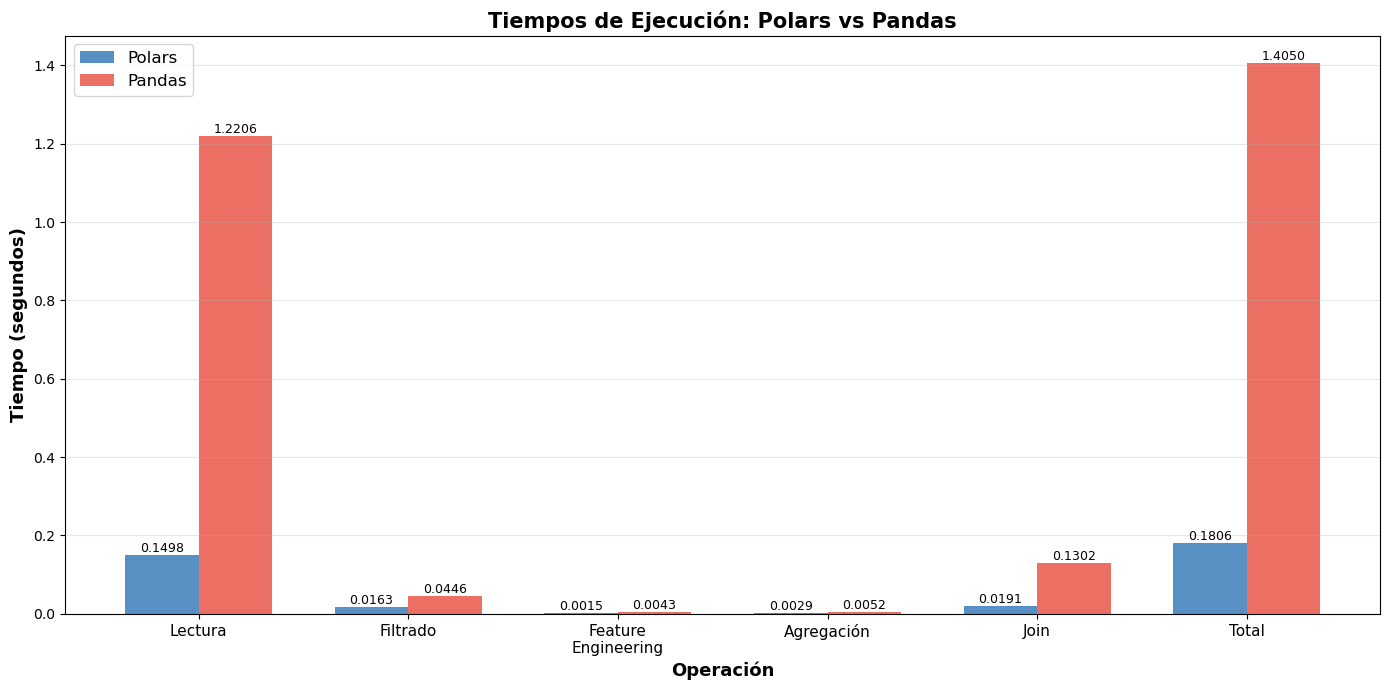

In [6]:
operaciones = ['Lectura', 'Filtrado', 'Feature\nEngineering', 'Agregación', 'Join', 'Total']
polars_vals = [0.1498, 0.0163, 0.0015, 0.0029, 0.0191, 0.1806]
pandas_vals = [1.2206, 0.0446, 0.0043, 0.0052, 0.1302, 1.4050]
speedup_vals = [8.67, 2.73, 2.95, 1.79, 6.82, 7.78]

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(operaciones))
width = 0.35

bars1 = ax.bar(x - width/2, polars_vals, width, label='Polars', color='#2E75B6', alpha=0.8)
bars2 = ax.bar(x + width/2, pandas_vals, width, label='Pandas', color='#E74C3C', alpha=0.8)

ax.set_ylabel('Tiempo (segundos)', fontsize=13, fontweight='bold')
ax.set_xlabel('Operación', fontsize=13, fontweight='bold')
ax.set_title('Tiempos de Ejecución: Polars vs Pandas', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(operaciones, fontsize=11)
ax.legend(fontsize=12, loc='upper left')
ax.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../figures/05_tiempos_ejecucion.png', dpi=300, bbox_inches='tight')
plt.show()


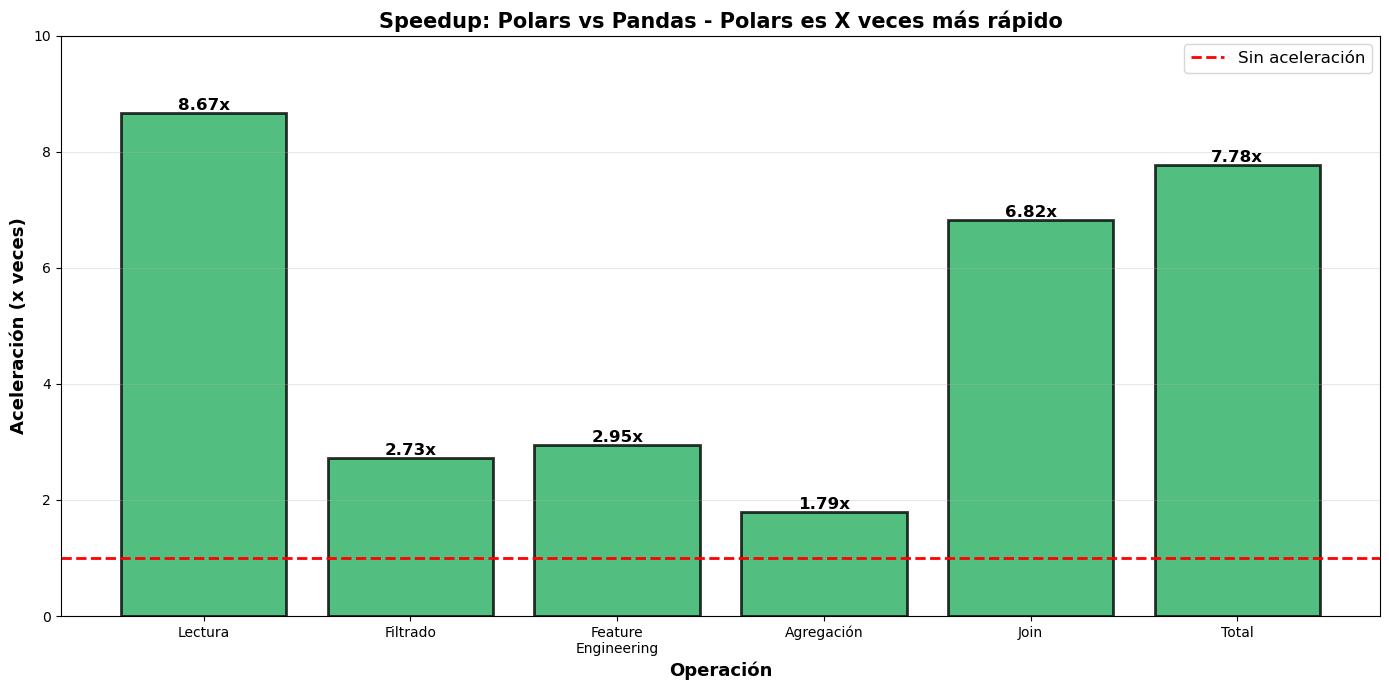

In [7]:
operaciones = ['Lectura', 'Filtrado', 'Feature\nEngineering', 'Agregación', 'Join', 'Total']
speedup_vals = [8.67, 2.73, 2.95, 1.79, 6.82, 7.78]

fig, ax = plt.subplots(figsize=(14, 7))

bars = ax.bar(operaciones, speedup_vals, color='#27AE60', alpha=0.8, edgecolor='black', linewidth=2)

ax.set_ylabel('Aceleración (x veces)', fontsize=13, fontweight='bold')
ax.set_xlabel('Operación', fontsize=13, fontweight='bold')
ax.set_title('Speedup: Polars vs Pandas - Polars es X veces más rápido', fontsize=15, fontweight='bold')
ax.axhline(y=1, color='red', linestyle='--', linewidth=2, label='Sin aceleración')
ax.set_ylim(0, 10)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)

# Valores en las barras
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}x',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../figures/speedup.png', dpi=300, bbox_inches='tight')
plt.show()
